# Informed & Metaheuristic Search Algorithms

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chebil/AI-course-book/blob/main/chapters/ch02_informed.ipynb)

## Overview

This notebook explores **five search/optimisation algorithms** across two classic AI problems.

### Problems
| Problem | Why chosen |
|---------|-----------|
| **8-Puzzle** | Finite state space — A* shines with a heuristic, direct comparison to uninformed search |
| **N-Queens (N = 8)** | Classic constraint-satisfaction / optimisation benchmark — exposes local optima perfectly |

### Algorithms
| Algorithm | Family | Problem used | Key idea |
|-----------|--------|-------------|----------|
| **A\*** | Informed search | 8-Puzzle | Best-first with $f(n)=g(n)+h(n)$ |
| **Hill Climbing** | Local search | N-Queens | Greedily move to best neighbour |
| **Simulated Annealing** | Local search | N-Queens | Accept bad moves probabilistically (cooling) |
| **Tabu Search** | Local search | N-Queens | Forbid recently visited moves to escape plateaus |
| **Genetic Algorithm** | Evolutionary | N-Queens | Evolve a population via selection, crossover, mutation |

```
8-Puzzle goal                     N-Queens goal (N=8)
┌───┬───┬───┐                     Q . . . . . . .
│ 1 │ 2 │ 3 │                     . . . . Q . . .
├───┼───┼───┤                     . . . . . . . Q
│ 4 │ 5 │ 6 │                     . . . . . Q . .
├───┼───┼───┤                     . . Q . . . . .
│ 7 │ 8 │   │                     . . . . . . Q .
└───┴───┴───┘                     . Q . . . . . .
                                  . . . Q . . . .
```


In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "ipywidgets", "matplotlib", "--quiet"], check=False)
print("Dependencies ready.")


Dependencies ready.


In [2]:
import heapq, time, random, math, copy
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("All imports successful ✓")


All imports successful ✓


---
## Part 1 — Problem Definitions

### Problem A: 8-Puzzle
Same representation as in `uninformed.ipynb` — a 9-tuple where `0` is the blank.  
**Used for:** A*

### Problem B: N-Queens
Place N queens on an N×N chessboard so that **no two queens attack each other**.

**State:** a tuple of length N where `state[i]` = column of the queen in row `i`.  
**Constraint:** no two queens share the same column, row, or diagonal.  
**Objective:** minimise the number of attacking pairs → 0 = solved.

```
Board (N=8):  state = (0, 4, 7, 5, 2, 6, 1, 3)
Row 0 → col 0:  Q . . . . . . .
Row 1 → col 4:  . . . . Q . . .
Row 2 → col 7:  . . . . . . . Q
...
```
Since rows are distinct by construction, only **column** and **diagonal** conflicts matter.

**Used for:** Hill Climbing, Simulated Annealing, Tabu Search, Genetic Algorithm


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PROBLEM A: 8-PUZZLE CORE  (used by A*)
# ═══════════════════════════════════════════════════════════════════════════════

GOAL_8 = (1, 2, 3, 4, 5, 6, 7, 8, 0)
# Pre-compute goal positions for each tile (row, col)
GOAL_POS = {tile: (i // 3, i % 3) for i, tile in enumerate(GOAL_8)}
GOAL_XY = GOAL_POS.copy()

def puzzle_get_blank(state):
    idx = state.index(0)
    return idx // 3, idx % 3

def puzzle_neighbors(state):
    row, col = puzzle_get_blank(state)
    blank = row * 3 + col
    result = []
    for dr, dc, name in [(-1,0,"Up"),(1,0,"Down"),(0,-1,"Left"),(0,1,"Right")]:
        nr, nc = row+dr, col+dc
        if 0 <= nr < 3 and 0 <= nc < 3:
            lst = list(state)
            nb = nr*3+nc
            lst[blank], lst[nb] = lst[nb], lst[blank]
            result.append((name, tuple(lst)))
    return result

def manhattan_h(state):
    """Manhattan distance heuristic — admissible & consistent."""
    dist = 0
    for i, tile in enumerate(state):
        if tile == 0:
            continue
        gr, gc = GOAL_XY[tile]
        cr, cc = i // 3, i % 3
        dist += abs(gr - cr) + abs(gc - cc)
    return dist

def reconstruct_puzzle_path(came_from, start, goal):
    path, state = [], goal
    while state != start:
        move, prev = came_from[state]
        path.append((move, state))
        state = prev
    path.reverse()
    return path

def count_inversions(state):
    t = [v for v in state if v != 0]
    return sum(1 for i in range(len(t)) for j in range(i+1,len(t)) if t[i]>t[j])

def is_solvable_puzzle(state):
    return count_inversions(state) % 2 == 0

# ── Quick check ────────────────────────────────────────────────────────────────
START_8 = (1, 2, 5, 3, 4, 0, 6, 7, 8)
print(f"8-Puzzle start : {START_8}")
print(f"Manhattan h    : {manhattan_h(START_8)}")
print(f"Is solvable    : {is_solvable_puzzle(START_8)}  (inversions={count_inversions(START_8)})")


8-Puzzle start : (1, 2, 5, 3, 4, 0, 6, 7, 8)
Manhattan h    : 11
Is solvable    : True  (inversions=2)


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PROBLEM B: N-QUEENS CORE  (used by HC, SA, Tabu, GA)
# ═══════════════════════════════════════════════════════════════════════════════

N_QUEENS = 8   # board size — change here to experiment

def nq_conflicts(state):
    """Count attacking pairs of queens (column + diagonal conflicts)."""
    n = len(state)
    attacks = 0
    for i in range(n):
        for j in range(i + 1, n):
            if state[i] == state[j]:                   # same column
                attacks += 1
            elif abs(state[i] - state[j]) == j - i:    # same diagonal
                attacks += 1
    return attacks

def nq_random_state(n=N_QUEENS, rng=random):
    """Random queen placement — one queen per row, random column."""
    return tuple(rng.randint(0, n - 1) for _ in range(n))

def nq_permutation_state(n=N_QUEENS, rng=random):
    """Permutation state — each column exactly once (removes column conflicts)."""
    s = list(range(n))
    rng.shuffle(s)
    return tuple(s)

def nq_move_neighbors(state):
    """All states reachable by moving one queen to any other column in its row."""
    n = len(state)
    neighbors = []
    for row in range(n):
        for col in range(n):
            if col != state[row]:
                new = list(state)
                new[row] = col
                neighbors.append(tuple(new))
    return neighbors

def nq_swap_neighbors(state):
    """All states reachable by swapping two queens' columns (keeps permutation)."""
    n = len(state)
    neighbors = []
    for i in range(n):
        for j in range(i + 1, n):
            new = list(state)
            new[i], new[j] = new[j], new[i]
            neighbors.append(tuple(new))
    return neighbors

# ── Check ──────────────────────────────────────────────────────────────────────
sample_nq = nq_permutation_state()
print(f"Sample N-Queens state : {sample_nq}")
print(f"Conflicts             : {nq_conflicts(sample_nq)}")
print(f"Move-neighbors count  : {len(nq_move_neighbors(sample_nq))}")
print(f"Swap-neighbors count  : {len(nq_swap_neighbors(sample_nq))}")


Sample N-Queens state : (3, 4, 6, 7, 2, 5, 0, 1)
Conflicts             : 6
Move-neighbors count  : 56
Swap-neighbors count  : 28


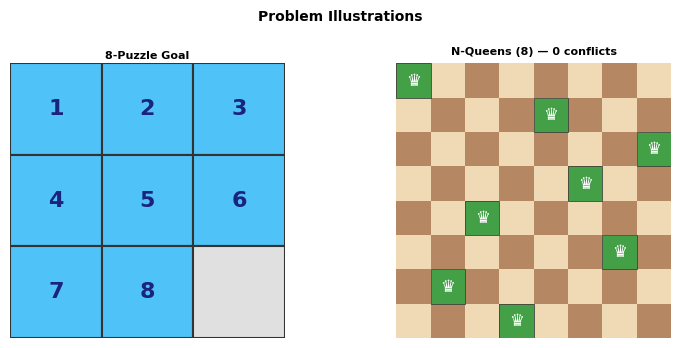

Visualisation helpers ready ✓


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
#  VISUALISATION HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

# ── 8-Puzzle ──────────────────────────────────────────────────────────────────
def draw_puzzle(ax, state, title="", color_map=None):
    ax.set_xlim(0, 3); ax.set_ylim(0, 3)
    ax.set_aspect("equal"); ax.axis("off")
    if title:
        ax.set_title(title, fontsize=8, pad=3, fontweight="bold")
    for idx, val in enumerate(state):
        r, c = idx//3, idx%3
        y = 2 - r
        if val == 0:
            fc = "#e0e0e0"; txt = ""
        else:
            fc = (color_map[val] if color_map else "#4fc3f7"); txt = str(val)
        ax.add_patch(plt.Rectangle([c, y], 1, 1, lw=1.5, ec="#333", fc=fc))
        if txt:
            ax.text(c+.5, y+.5, txt, ha="center", va="center",
                    fontsize=16, fontweight="bold", color="#1a237e")

def draw_puzzle_path(path, start, title="", max_show=14):
    states = [start] + [s for _,s in path]
    moves  = ["Start"] + [m for m,_ in path]
    if len(states) > max_show:
        states, moves = states[:max_show], moves[:max_show]
        truncated = True
    else:
        truncated = False
    n = len(states)
    fig, axes = plt.subplots(1, n, figsize=(n*1.9, 2.6))
    if n == 1: axes = [axes]
    fig.suptitle(title, fontsize=10, fontweight="bold", y=1.03)
    for i,(ax,st,mv) in enumerate(zip(axes, states, moves)):
        draw_puzzle(ax, st, title=f"[{i}] {mv}")
    if truncated:
        fig.text(.99, -.04, f"(first {max_show} of {len(path)+1})", ha="right", fontsize=7, color="gray")
    plt.tight_layout(); plt.show()

# ── N-Queens ──────────────────────────────────────────────────────────────────
def draw_queens(ax, state, title="", conflicts=None):
    n = len(state)
    ax.set_xlim(0, n); ax.set_ylim(0, n)
    ax.set_aspect("equal"); ax.axis("off")
    if title:
        ax.set_title(title, fontsize=8, pad=3, fontweight="bold")
    for r in range(n):
        for c in range(n):
            fc = "#f0d9b5" if (r + c) % 2 == 0 else "#b58863"
            ax.add_patch(plt.Rectangle([c, r], 1, 1, fc=fc, lw=0))
    # highlight conflicting queens
    conflict_rows = set()
    if conflicts is not None:
        for i in range(n):
            for j in range(i+1, n):
                if (state[i]==state[j] or abs(state[i]-state[j])==j-i):
                    conflict_rows.add(i); conflict_rows.add(j)
    for row, col in enumerate(state):
        fc = "#e53935" if row in conflict_rows else "#43a047"
        ax.add_patch(plt.Rectangle([col, n-1-row], 1, 1, fc=fc, lw=0.5, ec="#333"))
        ax.text(col+.5, n-row-.5, "♛", ha="center", va="center",
                fontsize=max(8, 20-n), color="white", fontweight="bold")

def draw_queens_large(state, title="", figsize=(4.5, 4.5)):
    fig, ax = plt.subplots(figsize=figsize)
    draw_queens(ax, state, title=title, conflicts=True)
    n = len(state)
    conf = nq_conflicts(state)
    ax.set_title(f"{title}\nConflicts: {conf}  {'✓ SOLVED' if conf==0 else ''}",
                 fontsize=9, fontweight="bold")
    plt.tight_layout(); plt.show()

def plot_convergence(histories, labels, colors, title="Convergence"):
    fig, ax = plt.subplots(figsize=(9, 3.5))
    for hist, lab, col in zip(histories, labels, colors):
        ax.plot(hist, label=lab, color=col, lw=1.8, alpha=0.85)
    ax.set_xlabel("Iteration"); ax.set_ylabel("Conflicts (lower = better)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, ls="--", alpha=0.4)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()

# ── Comparison bar chart ───────────────────────────────────────────────────────
def plot_algo_comparison(results):
    algos  = list(results.keys())
    colors = ["#4fc3f7","#81c784","#ffb74d","#ce93d8","#ef9a9a"][:len(algos)]
    metrics = {
        "Final Conflicts":   [r.get("conflicts", 0) for r in results.values()],
        "Iterations":        [r.get("iterations", 0) for r in results.values()],
        "Time (s)":          [r.get("time_s", 0)  for r in results.values()],
        "Solved (0/1)":      [int(r.get("conflicts",99)==0) for r in results.values()],
    }
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
    fig.suptitle("Algorithm Comparison — N-Queens", fontsize=11, fontweight="bold")
    for ax, (metric, vals) in zip(axes, metrics.items()):
        bars = ax.bar(algos, vals, color=colors, edgecolor="#333", lw=0.8)
        ax.set_title(metric, fontsize=9, fontweight="bold")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                    f"{val}" if isinstance(val,int) else f"{val:.4f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")
        ax.set_ylim(0, max(vals)*1.3+0.5)
        ax.spines[["top","right"]].set_visible(False)
        ax.tick_params(axis="x", labelsize=8)
    plt.tight_layout(); plt.show()

# ── Demo ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
draw_puzzle(axes[0], GOAL_8, title="8-Puzzle Goal")
draw_queens(axes[1], (0, 4, 7, 5, 2, 6, 1, 3), title="N-Queens Solution", conflicts=True)
axes[1].set_title("N-Queens (8) — 0 conflicts", fontsize=8, fontweight="bold")
plt.suptitle("Problem Illustrations", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()
print("Visualisation helpers ready ✓")


---
## Part 2 — A* Search (8-Puzzle)

### How it works
A* extends UCS by adding a **heuristic** $h(n)$ that estimates the remaining cost to the goal.

$$f(n) = g(n) + h(n)$$

| Term | Meaning |
|------|---------|
| $g(n)$ | Actual cost from start to $n$ |
| $h(n)$ | Estimated cost from $n$ to goal (heuristic) |
| $f(n)$ | Estimated total cost through $n$ |

```
PQ: [(f=h(start), g=0, start)]
while PQ not empty:
    f, g, node = heappop(PQ)
    if goal(node): return path
    for each neighbor:
        new_g = g + step_cost
        new_f = new_g + h(neighbor)
        if cheaper than seen: heappush(PQ, (new_f, new_g, neighbor))
```

### Heuristic: Manhattan Distance
$$h(n) = \sum_{i=1}^{8} \left( |row_i^{current} - row_i^{goal}| + |col_i^{current} - col_i^{goal}| \right)$$

- **Admissible** — never overestimates (each tile needs at least that many moves)  
- **Consistent** — satisfies the triangle inequality  
- Dramatically fewer nodes expanded than BFS/UCS

### Why A* > Uninformed Search
| | BFS/UCS | A\* |
|---|---|---|
| Guidance | None — blind | Heuristic directs search toward goal |
| Nodes expanded | $O(b^d)$ | Often $O(b^{d/2})$ in practice |
| Optimality | ✅ | ✅ (admissible h) |


In [6]:
# ─── A* Implementation ────────────────────────────────────────────────────────

def astar(start, heuristic=manhattan_h):
    """
    A* search for the 8-puzzle.

    Parameters
    ----------
    start     : 9-tuple  – initial state
    heuristic : callable(state) → int

    Returns
    -------
    dict: path, nodes_expanded, max_frontier, time_s, found, total_cost
    """
    if start == GOAL_8:
        return dict(path=[], nodes_expanded=0, max_frontier=1, time_s=0.0, found=True, total_cost=0)

    h0 = heuristic(start)
    counter   = 0
    # heap entry: (f, g, tie-break counter, state)
    frontier  = [(h0, 0, counter, start)]
    best_g    = {start: 0}          # best known g-cost per state
    came_from = {start: None}

    nodes_expanded = 0
    max_frontier   = 1
    t0             = time.perf_counter()

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        f, g, _, state = heapq.heappop(frontier)

        if g > best_g.get(state, float("inf")):
            continue                  # stale entry

        nodes_expanded += 1

        if state == GOAL_8:
            t1 = time.perf_counter()
            path = reconstruct_puzzle_path(came_from, start, state)
            return dict(path=path, nodes_expanded=nodes_expanded,
                        max_frontier=max_frontier,
                        time_s=round(t1-t0, 5), found=True, total_cost=g)

        for move, neighbor in puzzle_neighbors(state):
            new_g = g + 1
            if new_g < best_g.get(neighbor, float("inf")):
                best_g[neighbor]     = new_g
                came_from[neighbor]  = (move, state)
                counter += 1
                heapq.heappush(frontier, (new_g + heuristic(neighbor), new_g, counter, neighbor))

    t1 = time.perf_counter()
    return dict(path=[], nodes_expanded=nodes_expanded,
                max_frontier=max_frontier,
                time_s=round(t1-t0,5), found=False, total_cost=None)


# ── Run A* ────────────────────────────────────────────────────────────────────
print("=== A* (Manhattan Distance heuristic) ===")
print(f"  Start : {START_8}")
print(f"  h(start) = {manhattan_h(START_8)} (Manhattan distance)\n")

result_astar = astar(START_8)

if result_astar["found"]:
    print(f"  Solution depth    : {len(result_astar['path'])} moves")
    print(f"  Total cost        : {result_astar['total_cost']}")
    print(f"  Nodes expanded    : {result_astar['nodes_expanded']:,}")
    print(f"  Max frontier size : {result_astar['max_frontier']:,}")
    print(f"  Time              : {result_astar['time_s']} s")
    print(f"\n  Move sequence: {' → '.join(m for m,_ in result_astar['path'])}")
else:
    print("  No solution found.")


=== A* (Manhattan Distance heuristic) ===
  Start : (1, 2, 5, 3, 4, 0, 6, 7, 8)
  h(start) = 11 (Manhattan distance)

  Solution depth    : 21 moves
  Total cost        : 21
  Nodes expanded    : 862
  Max frontier size : 516
  Time              : 0.0284 s

  Move sequence: Down → Left → Up → Left → Down → Right → Right → Up → Left → Left → Up → Right → Right → Down → Left → Up → Left → Down → Down → Right → Right


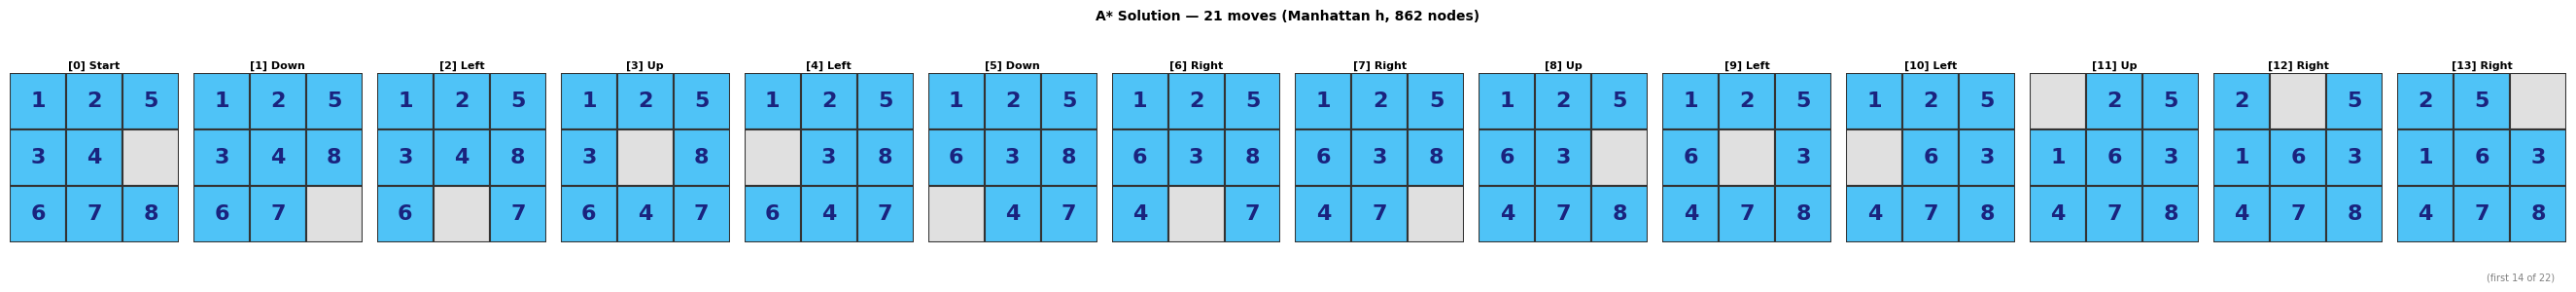

In [7]:
# ─── Visualise A* path ────────────────────────────────────────────────────────
if result_astar["found"]:
    draw_puzzle_path(result_astar["path"], START_8,
                     title=f"A* Solution — {len(result_astar['path'])} moves "
                           f"(Manhattan h, {result_astar['nodes_expanded']:,} nodes)")


In [8]:
# ─── A* vs BFS/UCS comparison on harder puzzles ──────────────────────────────

def bfs_puzzle(start):
    if start == GOAL_8:
        return dict(path=[], nodes_expanded=0, max_frontier=1, time_s=0.0, found=True, total_cost=0)
    frontier  = deque([start])
    visited   = {start}
    came_from = {start: None}
    nodes_expanded = 0
    max_frontier   = 1
    t0 = time.perf_counter()
    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        state = frontier.popleft()
        nodes_expanded += 1
        for move, nb in puzzle_neighbors(state):
            if nb not in visited:
                visited.add(nb)
                came_from[nb] = (move, state)
                if nb == GOAL_8:
                    path = reconstruct_puzzle_path(came_from, start, nb)
                    return dict(path=path, nodes_expanded=nodes_expanded,
                                max_frontier=max_frontier,
                                time_s=round(time.perf_counter()-t0,5),
                                found=True, total_cost=len(path))
                frontier.append(nb)
    return dict(path=[], nodes_expanded=nodes_expanded,
                max_frontier=max_frontier,
                time_s=round(time.perf_counter()-t0,5), found=False, total_cost=None)

# Test on a harder puzzle (more moves from goal)
def random_puzzle_from_goal(n_moves, seed=0):
    rng = random.Random(seed)
    state = GOAL_8
    for _ in range(n_moves):
        _, state = rng.choice(puzzle_neighbors(state))
    return state

HARD_START = random_puzzle_from_goal(25, seed=7)
print(f"Harder puzzle  : {HARD_START}")
print(f"Manhattan h    : {manhattan_h(HARD_START)}")
print(f"Solvable       : {is_solvable_puzzle(HARD_START)}\n")

r_b = bfs_puzzle(HARD_START)
r_a = astar(HARD_START)

print(f"{'':20s}  {'BFS':>10s}  {'A*':>10s}   Speedup")
print("-" * 55)
for label, b_val, a_val in [
    ("Nodes expanded", f"{r_b['nodes_expanded']:,}", f"{r_a['nodes_expanded']:,}"),
    ("Max frontier",   f"{r_b['max_frontier']:,}",   f"{r_a['max_frontier']:,}"),
    ("Solution depth", f"{len(r_b['path'])}",        f"{len(r_a['path'])}"),
    ("Time (s)",       f"{r_b['time_s']}",           f"{r_a['time_s']}"),
]:
    speedup = ""
    if label == "Nodes expanded":
        ratio = r_b['nodes_expanded'] / max(r_a['nodes_expanded'],1)
        speedup = f"A* expands {ratio:.1f}× fewer nodes"
    print(f"  {label:20s}  {b_val:>10s}  {a_val:>10s}   {speedup}")


Harder puzzle  : (4, 1, 3, 2, 6, 0, 7, 5, 8)
Manhattan h    : 7
Solvable       : True

                             BFS          A*   Speedup
-------------------------------------------------------
  Nodes expanded                96          10   A* expands 9.6× fewer nodes
  Max frontier                  74          11   
  Solution depth                 7           7   
  Time (s)                 0.00086     0.00041   


---
## Part 3 — Hill Climbing (N-Queens)

### How it works
Hill Climbing is the simplest local search strategy.  
At each step, move to the **best neighbour** (lower conflicts).  
Stop when no neighbour improves the current state — a **local minimum**.

```
state = random start
while True:
    best_neighbour = argmin(conflicts(n) for n in neighbours(state))
    if conflicts(best_neighbour) >= conflicts(state):
        break          # stuck at local optimum
    state = best_neighbour
```

### Variants used
| Variant | Strategy |
|---------|---------|
| **Steepest ascent** | Always move to the globally best neighbour |
| **Random restart** | Re-run from a new random start when stuck |

### Weakness
Hill Climbing gets trapped in **local optima** — states that are better than all neighbours but not optimal.  
For 8-Queens, ~14% of random starts lead directly to a solution; the rest get stuck.


In [9]:
# ─── Hill Climbing (Steepest-Ascent with Random Restart) ─────────────────────

def hill_climbing(n=N_QUEENS, max_restarts=100, seed=SEED):
    """
    Steepest-ascent Hill Climbing with random restarts for N-Queens.

    Uses move neighbours (every queen can move to any column in its row).
    Each restart begins from a fresh random permutation.

    Returns
    -------
    dict: state, conflicts, history (best cost per step), iterations,
          restarts_used, time_s, found
    """
    rng = random.Random(seed)
    t0  = time.perf_counter()
    total_iters = 0
    history     = []

    for restart in range(max_restarts):
        state    = nq_random_state(n, rng)
        cost     = nq_conflicts(state)
        history.append(cost)

        while True:
            total_iters += 1
            neighbors   = nq_move_neighbors(state)
            best_nb     = min(neighbors, key=nq_conflicts)
            best_cost   = nq_conflicts(best_nb)

            if best_cost < cost:
                state, cost = best_nb, best_cost
                history.append(cost)
            else:
                break          # local minimum

            if cost == 0:
                return dict(state=state, conflicts=0, history=history,
                            iterations=total_iters, restarts_used=restart+1,
                            time_s=round(time.perf_counter()-t0, 5), found=True)

    # Return best found even if not 0
    return dict(state=state, conflicts=cost, history=history,
                iterations=total_iters, restarts_used=max_restarts,
                time_s=round(time.perf_counter()-t0, 5), found=(cost==0))


# ── Run ────────────────────────────────────────────────────────────────────────
result_hc = hill_climbing()

print("=== Hill Climbing (Steepest-Ascent + Random Restart) ===")
print(f"  Found solution  : {result_hc['found']}")
print(f"  Final conflicts : {result_hc['conflicts']}")
print(f"  Restarts used   : {result_hc['restarts_used']}")
print(f"  Total iterations: {result_hc['iterations']:,}")
print(f"  Time            : {result_hc['time_s']} s")
print(f"  State           : {result_hc['state']}")


=== Hill Climbing (Steepest-Ascent + Random Restart) ===
  Found solution  : True
  Final conflicts : 0
  Restarts used   : 2
  Total iterations: 10
  Time            : 0.00887 s
  State           : (6, 2, 7, 1, 4, 0, 5, 3)


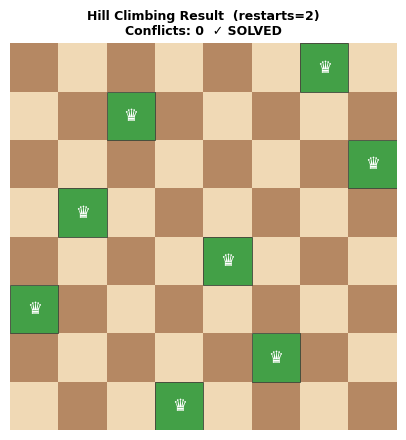

In [10]:
draw_queens_large(result_hc["state"],
                  title=f"Hill Climbing Result  (restarts={result_hc['restarts_used']})")


---
## Part 4 — Simulated Annealing (N-Queens)

### How it works
Simulated Annealing (SA) escapes local optima by **occasionally accepting worse moves**.  
The probability of accepting a worse move decreases over time as the **temperature** cools.

$$P(\text{accept worse}) = e^{-\Delta E / T}$$

```
T = T_initial
state = random start
while T > T_min:
    neighbour = random_neighbour(state)
    ΔE = conflicts(neighbour) - conflicts(state)
    if ΔE < 0:              # improvement → always accept
        state = neighbour
    elif random() < exp(-ΔE / T):   # worse → accept with probability
        state = neighbour
    T = T * cooling_rate    # lower temperature
```

### Analogy
The algorithm mimics **annealing in metallurgy** — metal heated, then slowly cooled to reach a low-energy crystalline state. High temperature = lots of randomness; low temperature = greedy.

### Key parameters
| Parameter | Effect |
|-----------|--------|
| `T_initial` | Higher → more initial exploration |
| `cooling_rate` (< 1) | Closer to 1 → slower cooling, better solution, slower runtime |
| `T_min` | When to stop |


In [11]:
# ─── Simulated Annealing ──────────────────────────────────────────────────────

def simulated_annealing(n=N_QUEENS, T_init=10.0, T_min=0.001,
                        cooling=0.995, max_iter=50_000, seed=SEED):
    """
    Simulated Annealing for N-Queens.

    At each step a random neighbour is generated (one queen moved to a random
    column). The acceptance probability follows the Boltzmann criterion.

    Returns
    -------
    dict: state, conflicts, history (cost per step), iterations, time_s, found
    """
    rng   = random.Random(seed)
    state = nq_random_state(n, rng)
    cost  = nq_conflicts(state)
    T     = T_init

    best_state, best_cost = state, cost
    history     = [cost]
    sample_every = max(1, max_iter // 500)

    t0 = time.perf_counter()
    for it in range(1, max_iter + 1):
        if T <= T_min or cost == 0:
            break

        # Random neighbour: pick a random row and move its queen
        row     = rng.randint(0, n - 1)
        col     = rng.randint(0, n - 1)
        new_state = list(state)
        new_state[row] = col
        new_state = tuple(new_state)
        new_cost  = nq_conflicts(new_state)

        delta = new_cost - cost
        if delta < 0 or rng.random() < math.exp(-delta / T):
            state, cost = new_state, new_cost
            if cost < best_cost:
                best_state, best_cost = state, cost

        T *= cooling
        if it % sample_every == 0:
            history.append(best_cost)

        if best_cost == 0:
            break

    return dict(state=best_state, conflicts=best_cost, history=history,
                iterations=it, time_s=round(time.perf_counter()-t0, 5),
                found=(best_cost == 0))


# ── Run ────────────────────────────────────────────────────────────────────────
result_sa = simulated_annealing()

print("=== Simulated Annealing ===")
print(f"  Found solution  : {result_sa['found']}")
print(f"  Final conflicts : {result_sa['conflicts']}")
print(f"  Iterations      : {result_sa['iterations']:,}")
print(f"  Time            : {result_sa['time_s']} s")
print(f"  State           : {result_sa['state']}")


=== Simulated Annealing ===
  Found solution  : True
  Final conflicts : 0
  Iterations      : 594
  Time            : 0.00984 s
  State           : (2, 4, 1, 7, 5, 3, 6, 0)


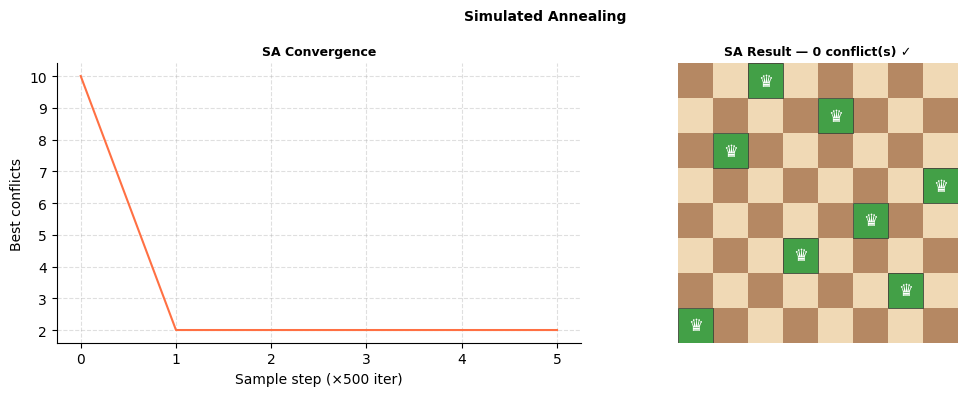

In [12]:
# ─── Visualise SA convergence & solution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Convergence curve
axes[0].plot(result_sa["history"], color="#ff7043", lw=1.5)
axes[0].set_title("SA Convergence", fontsize=9, fontweight="bold")
axes[0].set_xlabel("Sample step (×500 iter)"); axes[0].set_ylabel("Best conflicts")
axes[0].grid(True, ls="--", alpha=0.4)
axes[0].spines[["top","right"]].set_visible(False)

# Board
draw_queens(axes[1], result_sa["state"], conflicts=True)
c = result_sa["conflicts"]
axes[1].set_title(f"SA Result — {c} conflict(s) {'✓' if c==0 else ''}", fontsize=9, fontweight="bold")
plt.suptitle("Simulated Annealing", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Part 5 — Tabu Search (N-Queens)

### How it works
Tabu Search escapes local optima by **forbidding recently visited moves** (tabu list).  
Unlike SA, it is entirely **deterministic** after initialisation.

```
state     = random start
tabu_list = deque(maxlen=tabu_tenure)

while not stopping condition:
    candidates = [non-tabu neighbours]
    best       = argmin(conflicts(n) for n in candidates)
    
    if conflicts(best) == 0: return best
    
    state = best
    tabu_list.append(last_move)   # forbid reverse of this move
```

### Aspiration criterion
Even if a move is on the tabu list, **accept it if it leads to the best solution seen so far**.  
This prevents the tabu list from blocking globally optimal moves.

### Key parameters
| Parameter | Effect |
|-----------|--------|
| `tabu_tenure` | How long a move stays forbidden — too short = cycling, too long = missed moves |
| Neighbourhood | Move (one queen to any column) vs swap; move is richer |


In [13]:
# ─── Tabu Search ─────────────────────────────────────────────────────────────

def tabu_search(n=N_QUEENS, tabu_tenure=7, max_iter=5_000, seed=SEED):
    """
    Tabu Search for N-Queens.

    A move is identified as (row, old_col, new_col).
    Tabu list stores (row, new_col) pairs — the 'reverse' is (row, old_col).
    Aspiration: accept a tabu move if it improves the global best.

    Returns
    -------
    dict: state, conflicts, history, iterations, time_s, found
    """
    rng   = random.Random(seed)
    state = nq_random_state(n, rng)
    cost  = nq_conflicts(state)

    best_state, best_cost = state, cost
    tabu   = deque(maxlen=tabu_tenure * n)   # holds (row, col) forbidden destinations
    tabu_set = set()
    history  = [cost]

    t0 = time.perf_counter()
    for it in range(1, max_iter + 1):
        best_nb, best_nb_cost, best_move = None, float("inf"), None

        for row in range(n):
            for col in range(n):
                if col == state[row]:
                    continue
                new_state = list(state)
                new_state[row] = col
                new_state = tuple(new_state)
                nc = nq_conflicts(new_state)
                move = (row, col)

                # Accept if not tabu OR aspiration criterion
                if move not in tabu_set or nc < best_cost:
                    if nc < best_nb_cost:
                        best_nb, best_nb_cost, best_move = new_state, nc, move

        if best_nb is None:
            break

        # Update tabu list (forbid reversing this move)
        old_col = state[best_move[0]]
        reverse_move = (best_move[0], old_col)
        if reverse_move in tabu_set:
            pass  # already there
        tabu.append(reverse_move)
        tabu_set = set(tabu)

        state, cost = best_nb, best_nb_cost
        if cost < best_cost:
            best_state, best_cost = state, cost

        history.append(best_cost)
        if best_cost == 0:
            break

    return dict(state=best_state, conflicts=best_cost, history=history,
                iterations=it, time_s=round(time.perf_counter()-t0, 5),
                found=(best_cost == 0))


# ── Run ────────────────────────────────────────────────────────────────────────
result_tabu = tabu_search()

print("=== Tabu Search ===")
print(f"  Found solution  : {result_tabu['found']}")
print(f"  Final conflicts : {result_tabu['conflicts']}")
print(f"  Iterations      : {result_tabu['iterations']:,}")
print(f"  Time            : {result_tabu['time_s']} s")
print(f"  State           : {result_tabu['state']}")


=== Tabu Search ===
  Found solution  : True
  Final conflicts : 0
  Iterations      : 8
  Time            : 0.00549 s
  State           : (5, 3, 6, 0, 7, 1, 4, 2)


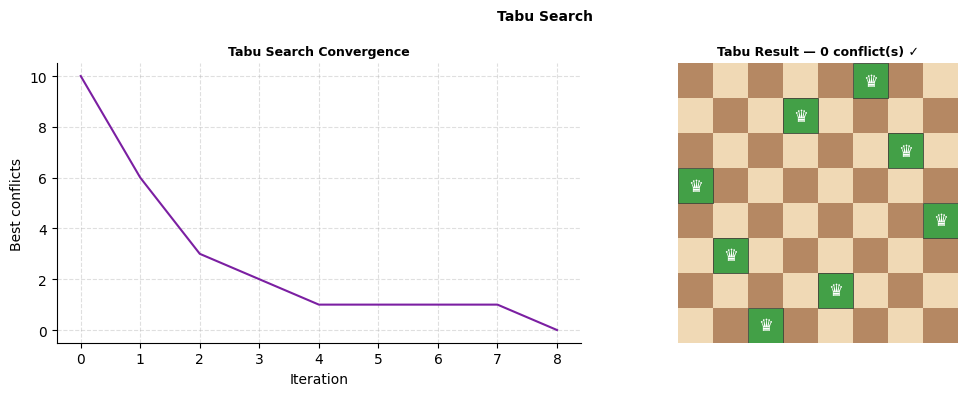

In [14]:
# ─── Visualise Tabu convergence & solution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(result_tabu["history"], color="#7b1fa2", lw=1.5)
axes[0].set_title("Tabu Search Convergence", fontsize=9, fontweight="bold")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Best conflicts")
axes[0].grid(True, ls="--", alpha=0.4)
axes[0].spines[["top","right"]].set_visible(False)

draw_queens(axes[1], result_tabu["state"], conflicts=True)
c = result_tabu["conflicts"]
axes[1].set_title(f"Tabu Result — {c} conflict(s) {'✓' if c==0 else ''}", fontsize=9, fontweight="bold")
plt.suptitle("Tabu Search", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Part 6 — Genetic Algorithm (N-Queens)

### How it works
A Genetic Algorithm (GA) evolves a **population of candidate solutions** through generations using biological operators.

```
population = [random_state() for _ in range(pop_size)]

for generation in range(max_gens):
    fitness   = [fitness_fn(s) for s in population]
    parents   = selection(population, fitness)    # favour low-conflict states
    offspring = [crossover(p1, p2) for p1,p2 in pairs(parents)]
    offspring = [mutate(c) for c in offspring]
    population = offspring
    if any(fitness(s)==0): return best
```

### Genetic operators for N-Queens
| Operator | Implementation |
|----------|---------------|
| **Representation** | Permutation chromosome — `state[i]` = column of queen in row `i` |
| **Fitness** | `max_possible_conflicts - nq_conflicts(state)` (higher = better) |
| **Selection** | Tournament selection (pick best of k random individuals) |
| **Crossover** | Order crossover (OX1) — preserves column permutation property |
| **Mutation** | Random swap of two genes — preserves permutation |

### Advantages over single-agent search
- Searches **multiple points** in the space simultaneously  
- Crossover can combine partial solutions from different individuals  
- Less likely to get permanently stuck in one local optimum


In [15]:
# ─── Genetic Algorithm ────────────────────────────────────────────────────────

def ga_fitness(state):
    """Higher = better. Max conflicts = n*(n-1)/2."""
    n = len(state)
    return n*(n-1)//2 - nq_conflicts(state)

def tournament_select(population, fitnesses, k=3, rng=random):
    """Pick k random individuals; return the one with highest fitness."""
    candidates = rng.sample(range(len(population)), k)
    return population[max(candidates, key=lambda i: fitnesses[i])]

def order_crossover(p1, p2, rng=random):
    """OX1: copy a segment from p1, fill remaining positions from p2 in order."""
    n  = len(p1)
    a, b = sorted(rng.sample(range(n), 2))
    child = [-1] * n
    child[a:b+1] = p1[a:b+1]
    fill = [x for x in p2 if x not in child[a:b+1]]
    idx  = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[idx]; idx += 1
    return tuple(child)

def mutate(state, mutation_rate=0.1, rng=random):
    """Swap two random genes with probability mutation_rate."""
    if rng.random() < mutation_rate:
        lst = list(state)
        i, j = rng.sample(range(len(lst)), 2)
        lst[i], lst[j] = lst[j], lst[i]
        return tuple(lst)
    return state

def genetic_algorithm(n=N_QUEENS, pop_size=200, max_gens=2000,
                      mutation_rate=0.1, elitism=2, seed=SEED):
    """
    Genetic Algorithm for N-Queens using permutation encoding.

    Parameters
    ----------
    pop_size      : population size per generation
    max_gens      : maximum number of generations
    mutation_rate : probability of applying mutation to an offspring
    elitism       : number of best individuals carried unchanged to next gen

    Returns
    -------
    dict: state, conflicts, history (best conflicts per gen), generations, time_s, found
    """
    rng = random.Random(seed)

    # Initialise population with permutations
    population = [nq_permutation_state(n, rng) for _ in range(pop_size)]
    best_state = min(population, key=nq_conflicts)
    best_cost  = nq_conflicts(best_state)
    history    = [best_cost]

    t0 = time.perf_counter()
    for gen in range(1, max_gens + 1):
        fitnesses  = [ga_fitness(s) for s in population]

        # Elitism: keep top individuals
        elite_idx  = sorted(range(pop_size), key=lambda i: fitnesses[i], reverse=True)[:elitism]
        new_pop    = [population[i] for i in elite_idx]

        # Fill rest via selection + crossover + mutation
        while len(new_pop) < pop_size:
            p1 = tournament_select(population, fitnesses, k=5, rng=rng)
            p2 = tournament_select(population, fitnesses, k=5, rng=rng)
            child = order_crossover(p1, p2, rng=rng)
            child = mutate(child, mutation_rate, rng=rng)
            new_pop.append(child)

        population = new_pop
        gen_best   = min(population, key=nq_conflicts)
        gen_cost   = nq_conflicts(gen_best)

        if gen_cost < best_cost:
            best_state, best_cost = gen_best, gen_cost

        history.append(best_cost)
        if best_cost == 0:
            break

    return dict(state=best_state, conflicts=best_cost, history=history,
                iterations=gen, time_s=round(time.perf_counter()-t0, 5),
                found=(best_cost == 0))


# ── Run ────────────────────────────────────────────────────────────────────────
result_ga = genetic_algorithm()

print("=== Genetic Algorithm ===")
print(f"  Found solution  : {result_ga['found']}")
print(f"  Final conflicts : {result_ga['conflicts']}")
print(f"  Generations     : {result_ga['iterations']:,}")
print(f"  Time            : {result_ga['time_s']} s")
print(f"  State           : {result_ga['state']}")


=== Genetic Algorithm ===
  Found solution  : True
  Final conflicts : 0
  Generations     : 2
  Time            : 0.01717 s
  State           : (2, 4, 1, 7, 0, 6, 3, 5)


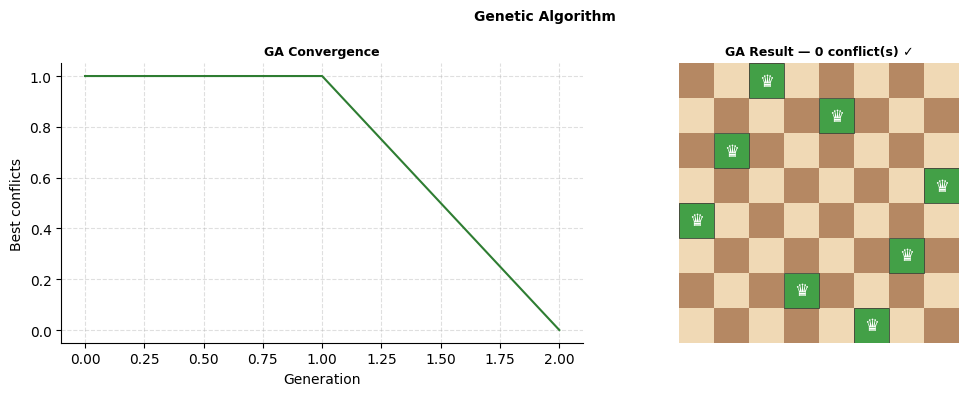

In [16]:
# ─── Visualise GA convergence & solution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(result_ga["history"], color="#2e7d32", lw=1.5)
axes[0].set_title("GA Convergence", fontsize=9, fontweight="bold")
axes[0].set_xlabel("Generation"); axes[0].set_ylabel("Best conflicts")
axes[0].grid(True, ls="--", alpha=0.4)
axes[0].spines[["top","right"]].set_visible(False)

draw_queens(axes[1], result_ga["state"], conflicts=True)
c = result_ga["conflicts"]
axes[1].set_title(f"GA Result — {c} conflict(s) {'✓' if c==0 else ''}", fontsize=9, fontweight="bold")
plt.suptitle("Genetic Algorithm", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Part 7 — Side-by-Side Convergence & Comparison

Overlay all four local-search/evolutionary algorithms on the **same N-Queens instance** to compare convergence speed and solution quality.


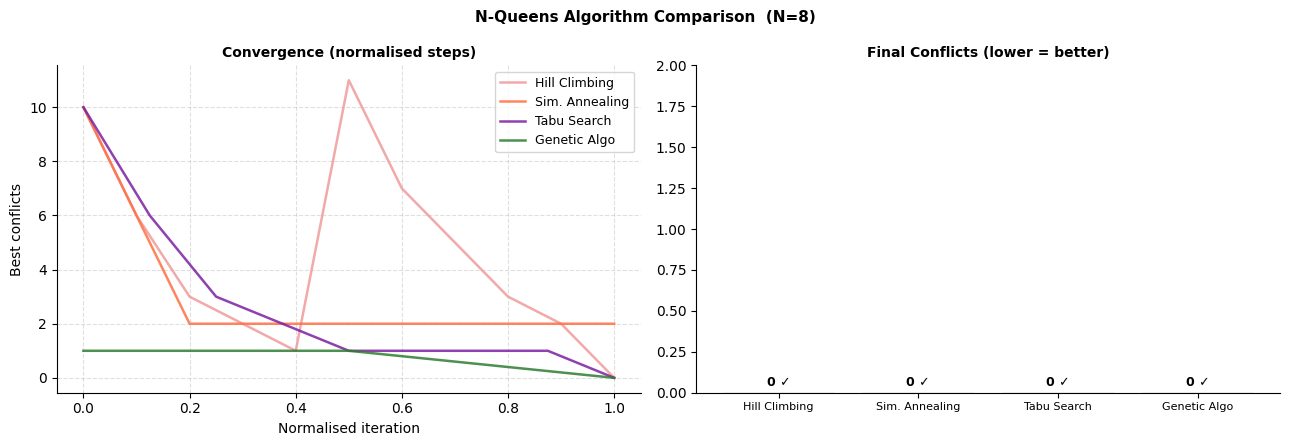

Algorithm           Solved  Conflicts      Iters   Time(s)
----------------------------------------------------------
  Hill Climbing          ✓          0         10   0.00887
  Sim. Annealing         ✓          0        594   0.00984
  Tabu Search            ✓          0          8   0.00549
  Genetic Algo           ✓          0          2   0.01717


In [17]:
# ─── Convergence overlay ─────────────────────────────────────────────────────
algos_nq = {
    "Hill Climbing":  (result_hc,   "#ef9a9a"),
    "Sim. Annealing": (result_sa,   "#ff7043"),
    "Tabu Search":    (result_tabu, "#7b1fa2"),
    "Genetic Algo":   (result_ga,   "#2e7d32"),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: convergence curves (normalise length)
for label, (res, col) in algos_nq.items():
    h = res["history"]
    xs = np.linspace(0, 1, len(h))
    axes[0].plot(xs, h, label=label, color=col, lw=1.8, alpha=0.85)
axes[0].set_title("Convergence (normalised steps)", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Normalised iteration"); axes[0].set_ylabel("Best conflicts")
axes[0].legend(fontsize=9); axes[0].grid(True, ls="--", alpha=0.4)
axes[0].spines[["top","right"]].set_visible(False)

# Right: bar chart — final conflicts
labels = list(algos_nq.keys())
colors = [v[1] for v in algos_nq.values()]
vals   = [v[0]["conflicts"] for v in algos_nq.values()]
bars   = axes[1].bar(labels, vals, color=colors, edgecolor="#333", lw=0.8)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+.02,
                 f"{val} {'✓' if val==0 else ''}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_title("Final Conflicts (lower = better)", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, max(vals)+2)
axes[1].spines[["top","right"]].set_visible(False)
axes[1].tick_params(axis="x", labelsize=8)

plt.suptitle(f"N-Queens Algorithm Comparison  (N={N_QUEENS})", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Metrics table ─────────────────────────────────────────────────────────────
header = f"{'Algorithm':<18} {'Solved':>7} {'Conflicts':>10} {'Iters':>10} {'Time(s)':>9}"
print(header); print("-"*len(header))
for label, (res, _) in algos_nq.items():
    print(f"  {label:<16} {'✓' if res['found'] else '✗':>7} "
          f"{res['conflicts']:>10} {res['iterations']:>10,} {res['time_s']:>9.5f}")


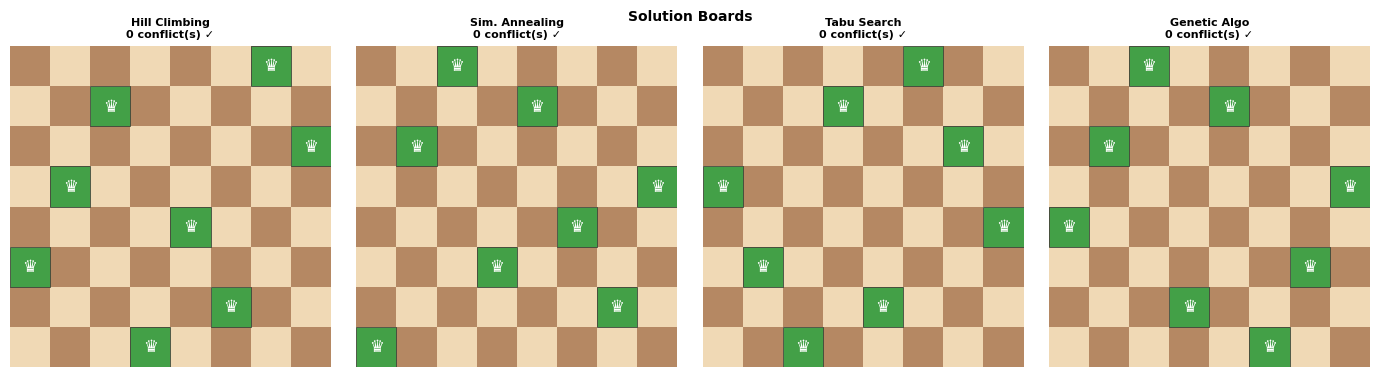

In [18]:
# ─── 4-board side-by-side solution view ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, (label, (res, col)) in zip(axes, algos_nq.items()):
    draw_queens(ax, res["state"], conflicts=True)
    c = res["conflicts"]
    ax.set_title(f"{label}\n{c} conflict(s) {'✓' if c==0 else '✗'}",
                 fontsize=8, fontweight="bold")
plt.suptitle("Solution Boards", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Part 8 — Interactive Comparison Widget

Tune algorithm parameters and run all four local-search methods on any N-Queens problem size.  
Compare solutions, convergence curves, and metrics in real time.


In [19]:
# ─── Interactive Widget ───────────────────────────────────────────────────────

style   = {"description_width": "160px"}
lw320   = widgets.Layout(width="340px")
lw200   = widgets.Layout(width="200px")

# ── Controls ──────────────────────────────────────────────────────────────────
w_n        = widgets.IntSlider(value=8, min=4, max=20, step=1,
                               description="Board size N:", style=style, layout=lw320)
w_seed     = widgets.IntText(value=42, description="Random seed:", style=style, layout=lw320)

w_hc_rest  = widgets.IntSlider(value=100, min=5, max=500, step=5,
                                description="HC max restarts:", style=style, layout=lw320)
w_sa_t0    = widgets.FloatSlider(value=10.0, min=1.0, max=50.0, step=1.0,
                                  description="SA T_initial:", style=style, layout=lw320)
w_sa_cool  = widgets.FloatSlider(value=0.995, min=0.90, max=0.9999, step=0.001,
                                  description="SA cooling rate:", style=style, layout=lw320,
                                  readout_format=".4f")
w_tabu_ten = widgets.IntSlider(value=7, min=2, max=30, step=1,
                                description="Tabu tenure:", style=style, layout=lw320)
w_ga_pop   = widgets.IntSlider(value=200, min=20, max=500, step=20,
                                description="GA pop size:", style=style, layout=lw320)
w_ga_mut   = widgets.FloatSlider(value=0.10, min=0.01, max=0.50, step=0.01,
                                  description="GA mutation rate:", style=style, layout=lw320)
w_ga_gens  = widgets.IntSlider(value=1000, min=100, max=5000, step=100,
                                description="GA max generations:", style=style, layout=lw320)

w_btn = widgets.Button(description="Run All Algorithms", button_style="primary",
                       icon="play", layout=widgets.Layout(width="220px", height="38px"))
w_out = widgets.Output()

sections = widgets.Accordion(children=[
    widgets.VBox([w_hc_rest]),
    widgets.VBox([w_sa_t0, w_sa_cool]),
    widgets.VBox([w_tabu_ten]),
    widgets.VBox([w_ga_pop, w_ga_mut, w_ga_gens]),
])
for i, title in enumerate(["Hill Climbing", "Simulated Annealing", "Tabu Search", "Genetic Algorithm"]):
    sections.set_title(i, title)

def on_run(b):
    with w_out:
        clear_output(wait=True)
        n    = w_n.value
        seed = w_seed.value
        print(f"Running on {n}-Queens  (seed={seed}) ...\n")

        r_hc   = hill_climbing(n=n, max_restarts=w_hc_rest.value,  seed=seed)
        print(f"  Hill Climbing   done  — conflicts={r_hc['conflicts']}")
        r_sa   = simulated_annealing(n=n, T_init=w_sa_t0.value,
                                     cooling=w_sa_cool.value, seed=seed)
        print(f"  Sim. Annealing  done  — conflicts={r_sa['conflicts']}")
        r_tabu = tabu_search(n=n, tabu_tenure=w_tabu_ten.value, seed=seed)
        print(f"  Tabu Search     done  — conflicts={r_tabu['conflicts']}")
        r_ga   = genetic_algorithm(n=n, pop_size=w_ga_pop.value,
                                   max_gens=w_ga_gens.value,
                                   mutation_rate=w_ga_mut.value, seed=seed)
        print(f"  Genetic Algo    done  — conflicts={r_ga['conflicts']}\n")

        results_all = {
            "HC":    r_hc,
            "SA":    r_sa,
            "Tabu":  r_tabu,
            "GA":    r_ga,
        }
        colors_all = ["#ef9a9a","#ff7043","#7b1fa2","#2e7d32"]

        # Metrics table
        header = f"{'Algorithm':<8} {'Solved':>7} {'Conflicts':>10} {'Iters':>10} {'Time(s)':>9}"
        print(header); print("-"*len(header))
        for lbl, r in results_all.items():
            print(f"  {lbl:<6} {'✓' if r['found'] else '✗':>7} "
                  f"{r['conflicts']:>10} {r['iterations']:>10,} {r['time_s']:>9.5f}")
        print()

        # Convergence overlay
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        for (lbl, r), col in zip(results_all.items(), colors_all):
            h  = r["history"]
            xs = np.linspace(0, 1, len(h))
            axes[0].plot(xs, h, label=lbl, color=col, lw=1.8, alpha=0.85)
        axes[0].set_title("Convergence", fontsize=10, fontweight="bold")
        axes[0].set_xlabel("Normalised iteration"); axes[0].set_ylabel("Best conflicts")
        axes[0].legend(fontsize=9); axes[0].grid(True, ls="--", alpha=0.4)
        axes[0].spines[["top","right"]].set_visible(False)

        bars = axes[1].bar(list(results_all.keys()),
                           [r["conflicts"] for r in results_all.values()],
                           color=colors_all, edgecolor="#333", lw=0.8)
        for bar, r in zip(bars, results_all.values()):
            c = r["conflicts"]
            axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+.05,
                         f"{c} {'✓' if c==0 else ''}",
                         ha="center", va="bottom", fontsize=9, fontweight="bold")
        axes[1].set_title("Final Conflicts", fontsize=10, fontweight="bold")
        axes[1].set_ylim(0, max(r["conflicts"] for r in results_all.values())+2)
        axes[1].spines[["top","right"]].set_visible(False)
        plt.suptitle(f"{n}-Queens Comparison", fontsize=11, fontweight="bold")
        plt.tight_layout(); plt.show()

        # Solution boards
        fig2, axes2 = plt.subplots(1, 4, figsize=(14, 3.8))
        for ax, (lbl, r), col in zip(axes2, results_all.items(), colors_all):
            draw_queens(ax, r["state"], conflicts=True)
            c = r["conflicts"]
            ax.set_title(f"{lbl}\n{c} conflicts {'✓' if c==0 else '✗'}",
                         fontsize=8, fontweight="bold")
        plt.suptitle("Solution Boards", fontsize=10, fontweight="bold")
        plt.tight_layout(); plt.show()

w_btn.on_click(on_run)

ui = widgets.VBox([
    widgets.HTML("<h3 style='margin-bottom:4px'>♛ N-Queens Solver</h3>"),
    widgets.HTML("<p style='font-size:12px;color:#555'>Configure parameters and compare all four local-search algorithms.</p>"),
    widgets.HBox([w_n, w_seed]),
    sections,
    w_btn,
    w_out,
])
display(ui)


---
## Part 9 — Scalability Analysis

Benchmark all algorithms as $N$ increases (4 → 20 queens).  
Plots show how **solve rate**, **final conflicts**, and **time** scale with board size.


In [20]:
# ─── Scalability benchmark ────────────────────────────────────────────────────
import statistics

Ns       = [4, 6, 8, 10, 12, 14, 16, 18, 20]
N_RUNS   = 3      # runs per N to average

scale = {a: {"conflicts":[], "time_s":[], "solved":[]}
         for a in ["HC","SA","Tabu","GA"]}

print(f"{'N':>4}  {'Run':>4}  {'HC':>5}  {'SA':>5}  {'Tabu':>6}  {'GA':>5}")
print("-" * 44)

for n in Ns:
    hc_c, sa_c, tb_c, ga_c = [], [], [], []
    hc_t, sa_t, tb_t, ga_t = [], [], [], []
    for run in range(N_RUNS):
        s = run * 17
        r_hc   = hill_climbing(n=n, max_restarts=max(30, n*5), seed=s)
        r_sa   = simulated_annealing(n=n, max_iter=n*3000, seed=s)
        r_tb   = tabu_search(n=n, tabu_tenure=max(5,n//2), max_iter=n*500, seed=s)
        r_ga   = genetic_algorithm(n=n, pop_size=min(300,n*20),
                                   max_gens=max(500, n*100), seed=s)
        hc_c.append(r_hc["conflicts"]); hc_t.append(r_hc["time_s"])
        sa_c.append(r_sa["conflicts"]); sa_t.append(r_sa["time_s"])
        tb_c.append(r_tb["conflicts"]); tb_t.append(r_tb["time_s"])
        ga_c.append(r_ga["conflicts"]); ga_t.append(r_ga["time_s"])
        print(f"{n:>4}  {run:>4}  {r_hc['conflicts']:>5}  {r_sa['conflicts']:>5}"
              f"  {r_tb['conflicts']:>6}  {r_ga['conflicts']:>5}")

    for lbl, cc, tt in [("HC",hc_c,hc_t),("SA",sa_c,sa_t),("Tabu",tb_c,tb_t),("GA",ga_c,ga_t)]:
        scale[lbl]["conflicts"].append(statistics.mean(cc))
        scale[lbl]["time_s"].append(statistics.mean(tt))
        scale[lbl]["solved"].append(sum(1 for v in cc if v==0) / N_RUNS)

print("\nBenchmark complete.")


   N   Run     HC     SA    Tabu     GA
--------------------------------------------
   4     0      0      0       0      0
   4     1      0      0       0      0
   4     2      0      0       0      0
   6     0      0      0       1      0
   6     1      0      0       0      0
   6     2      0      0       0      0
   8     0      0      0       0      0
   8     1      0      1       0      0
   8     2      0      0       0      0
  10     0      0      1       0      0
  10     1      0      0       0      0
  10     2      0      1       0      0
  12     0      0      0       0      0
  12     1      0      0       0      0
  12     2      0      1       0      0
  14     0      0      1       0      0
  14     1      0      0       0      0
  14     2      0      1       0      0
  16     0      0      1       0      0
  16     1      0      0       0      0
  16     2      0      1       0      0
  18     0      0      0       0      0
  18     1      0      1       0   

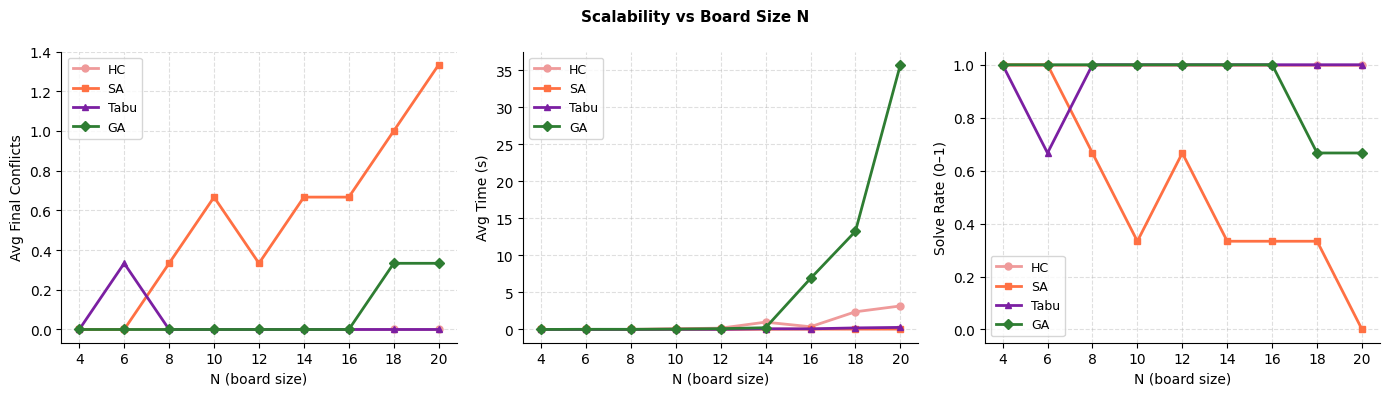

In [21]:
# ─── Plot scalability ─────────────────────────────────────────────────────────
pal = {"HC":"#ef9a9a","SA":"#ff7043","Tabu":"#7b1fa2","GA":"#2e7d32"}
mks = {"HC":"o","SA":"s","Tabu":"^","GA":"D"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Scalability vs Board Size N", fontsize=11, fontweight="bold")
metrics_scale = [
    ("conflicts", "Avg Final Conflicts"),
    ("time_s",    "Avg Time (s)"),
    ("solved",    "Solve Rate (0–1)"),
]
for ax, (key, ylabel) in zip(axes, metrics_scale):
    for algo in ["HC","SA","Tabu","GA"]:
        ax.plot(Ns, scale[algo][key],
                color=pal[algo], marker=mks[algo], lw=2, markersize=5, label=algo)
    ax.set_xlabel("N (board size)"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True, ls="--", alpha=0.4)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout(); plt.show()


---
## Part 10 — Summary & Key Takeaways

### A* vs Uninformed Search (8-Puzzle)
| | BFS/UCS | A* |
|---|---|---|
| Guidance | None | Manhattan distance heuristic |
| Nodes expanded (typical) | Tens of thousands | Hundreds |
| Optimality | ✅ | ✅ (admissible h) |
| Memory | $O(b^d)$ | $O(b^d)$ but much smaller in practice |

### Local Search / Metaheuristics (N-Queens)
| Algorithm | Escapes local optima? | Memory | Deterministic | Parallelism |
|---|---|---|---|---|
| **Hill Climbing** | ⚠️ Only via restart | $O(N)$ | ✅ | ✅ Easy |
| **Sim. Annealing** | ✅ Probabilistic | $O(N)$ | ❌ Stochastic | ✅ Easy |
| **Tabu Search** | ✅ Tabu list + aspiration | $O(tabu\_tenure)$ | ✅ | ⚠️ Harder |
| **Genetic Algorithm** | ✅ Population diversity | $O(pop\_size \cdot N)$ | ❌ Stochastic | ✅ Natural |

### When to choose which algorithm?
- **A\*** — when the state space is a graph with a good admissible heuristic (pathfinding, puzzle-solving)  
- **Hill Climbing** — fastest, but only reliable for easy instances; use with random restarts  
- **Simulated Annealing** — general-purpose; tune cooling schedule for quality/speed tradeoff  
- **Tabu Search** — strong for combinatorial problems; good when a memory of recent moves helps  
- **Genetic Algorithm** — excels when solutions can be combined; great for large, multimodal landscapes

